# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  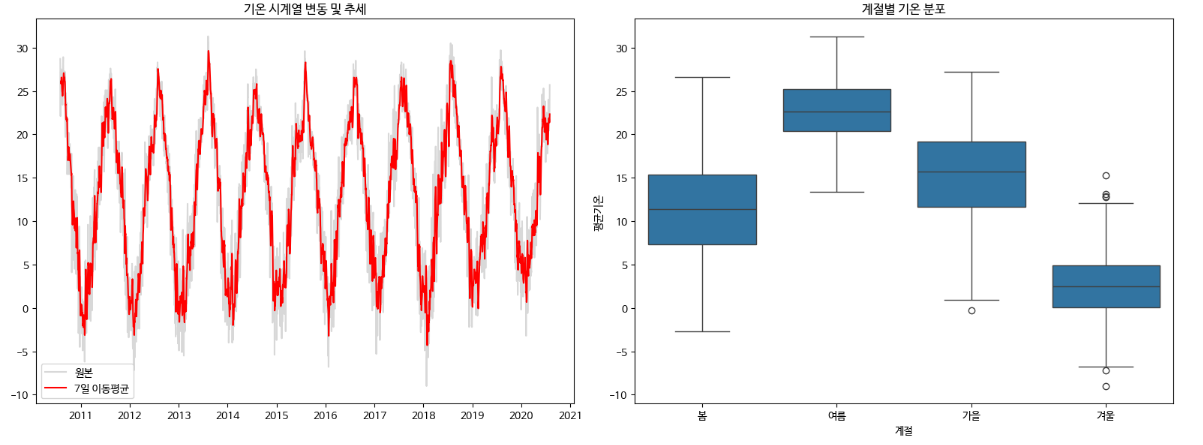

  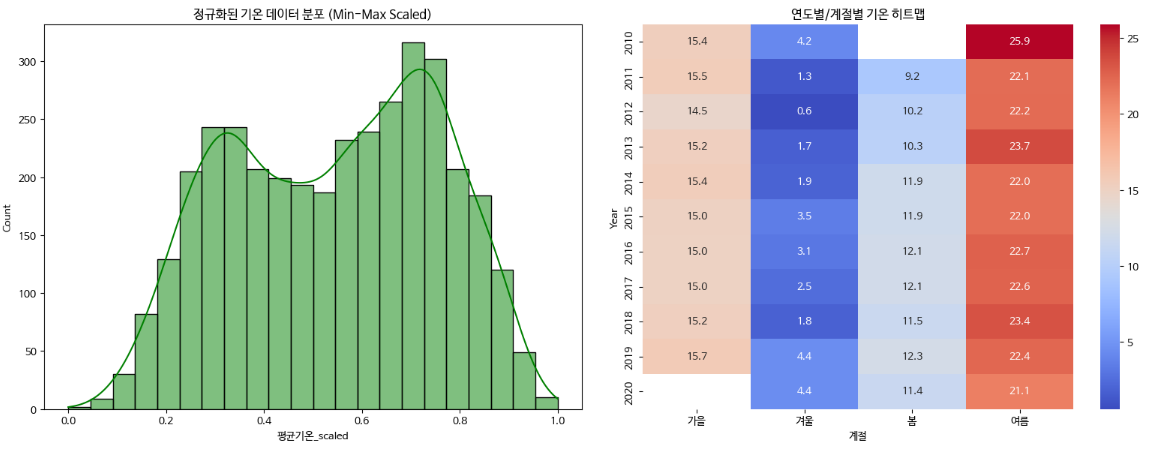



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm

def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가 (문제의 원인 해결)
    # FontProperties 대신 font_manager.fontManager.addfont를 사용.
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    # 'NanumBarunGothic'은 나눔폰트 파일의 실제 이름입니다.
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")

# 데이터 불러오기 함수
def load_data(file_path):
    df = pd.read_csv(file_path, encoding='cp949')
    return df

# 데이터 전처리 함수
def preprocess_data(df):
    df = df[['일시', '평균기온', '최대풍속', '평균풍속']]
    df = df.dropna()

    return df

# Min-Max Scaling 함수
def min_max_scaling(df, columns):
    for col in columns:
        min_value = df[col].min()
        max_value = df[col].max()

        df[col + '_scaled'] = ((df[col] - min_value) / (max_value - min_value))

    return df

# 시계열 처리 함수
def time_series_processing(df):
    df['일시'] = pd.to_datetime(df['일시'])

    df = df.set_index('일시')

    df['평균기온_7일이동평균'] = (df['평균기온'].rolling(window=7).mean())

    return df

# 계절 컬럼 추가 함수
def add_season_column(df):
    def get_season(month):
        if month in [3, 4, 5]:
            return '봄'
        elif month in [6, 7, 8]:
            return '여름'
        elif month in [9, 10, 11]:
            return '가을'
        else:
            return '겨울'

    df['계절'] = df.index.month.map(get_season)

    return df

# 계절별 통계 함수
def seasonal_statistics(df):
    season_stats = df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].mean()

    return season_stats

# 피벗 테이블 함수
def yearly_pivot_table(df):
    df['연도'] = df.index.year

    pivot_df = pd.pivot_table(df, values='평균기온', index='연도', columns='계절', aggfunc='mean')

    return pivot_df

# 그래프 생성 함수
def create_graphs(df, pivot_df):
    plt.figure(figsize=(16, 10))

    plt.subplot(2, 2, 1)
    plt.plot(df.index, df['평균기온'], color='gray', alpha=0.5, label='원본')
    plt.plot(df.index, df['평균기온_7일이동평균'], color='red', label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend(loc='lower left')

    plt.subplot(2, 2, 2)
    sns.boxplot(x='계절', y='평균기온', data=df, order=['봄', '여름', '가을', '겨울'])
    plt.title('계절별 기온 분포')

    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온_scaled'], bins=20, kde=True, color='green')
    plt.title('정규화된 기온 데이터 분포')

    plt.subplot(2, 2, 4)
    sns.heatmap(pivot_df, annot=True, cmap='coolwarm', fmt='.1f')
    plt.title('연도별/계절별 평균기온 히트맵')
    plt.tight_layout()
    plt.show()

# 엑셀 저장 함수
def save_to_excel(preprocessed_df, season_stats, pivot_df):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        preprocessed_df.to_excel(writer, sheet_name='전처리데이터')

        season_stats.to_excel(writer, sheet_name='계절별통계')

        pivot_df.to_excel(writer, sheet_name='연도별피벗테이블')

    print("weather_analysis_report.xlsx 저장 완료")

✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)


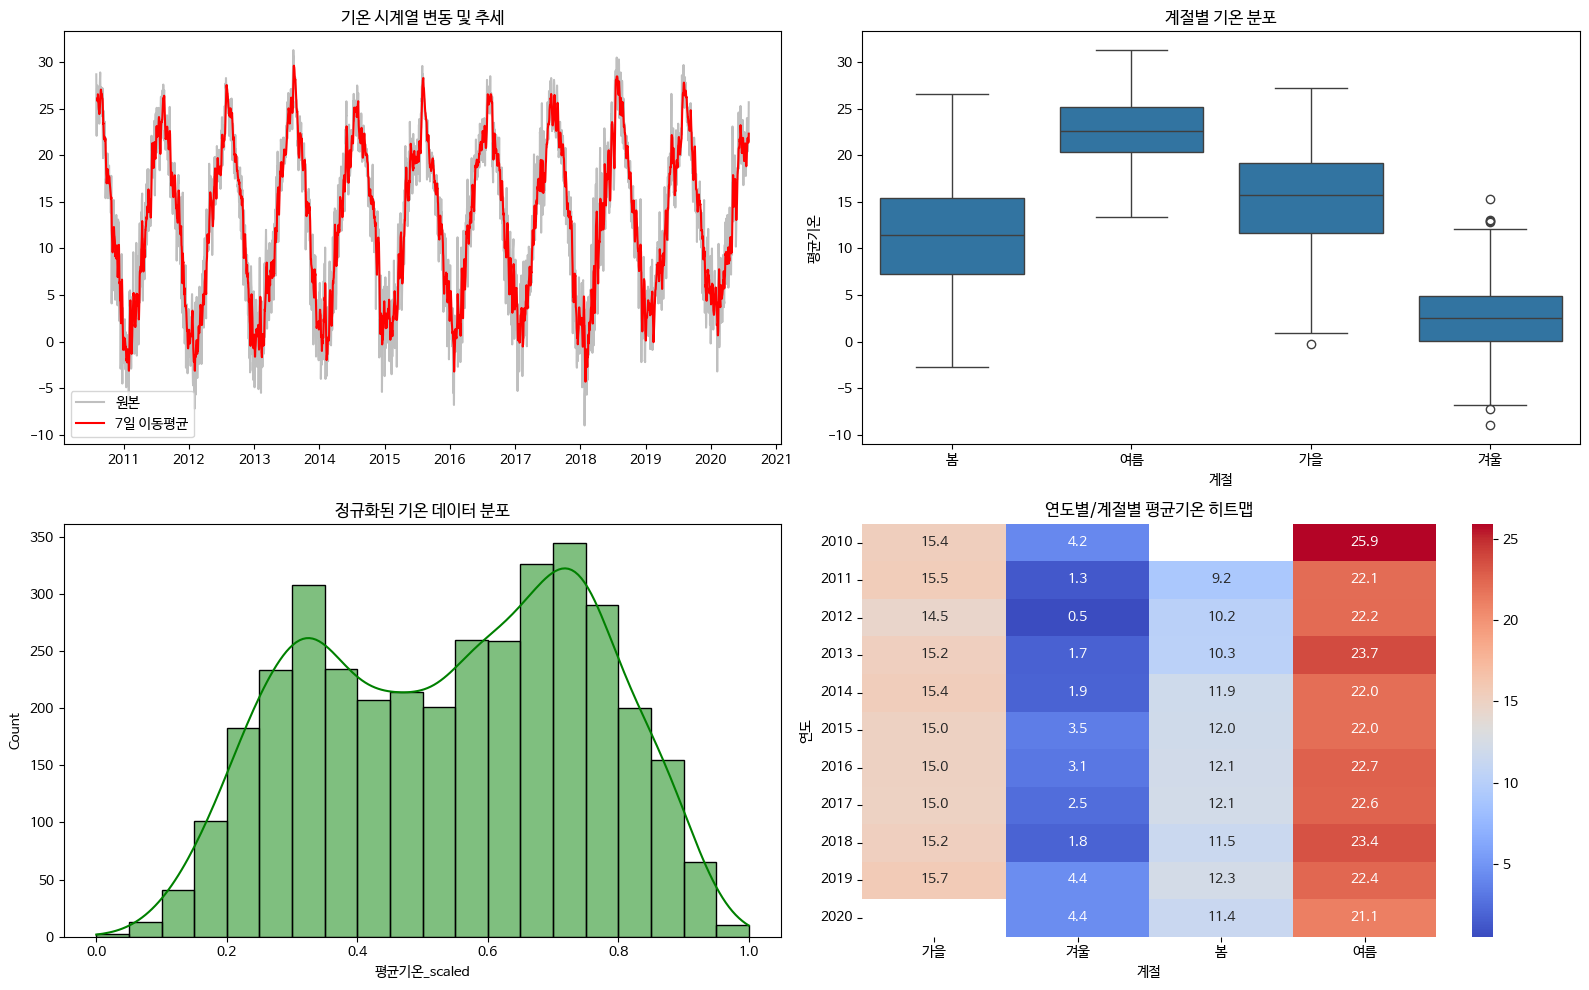

weather_analysis_report.xlsx 저장 완료


In [18]:
if __name__ == "__main__":
    setup_korean_font()

    df = load_data('weather.csv')

    df = preprocess_data(df)

    scale_columns = ['평균기온','최대풍속','평균풍속']

    df = min_max_scaling(df, scale_columns)

    df = time_series_processing(df)

    df = add_season_column(df)

    season_stats = seasonal_statistics(df)

    pivot_df = yearly_pivot_table(df)

    create_graphs(df, pivot_df)

    save_to_excel(df, season_stats, pivot_df)